# NFL Draft Pillar Analysis v3

Downstream analysis using the v3 2-bin pillar scores (`score_god_given`, `score_learned`) as NLP-derived features.

**Four lenses:**
1. **EDA** — do scores correlate with grade / career outcomes?
2. **Contract prediction** — logistic regression vs random forest, NLP vs grade vs combined
3. **Grade prediction** — how much of the scout's grade is explained by their own language?
4. **Reach / steal analysis** — grade vs draft round residuals, explained by pillar scores

In [2]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import average_precision_score, roc_auc_score, make_scorer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

YEAR_MIN, YEAR_MAX = 2014, 2021   # contract outcome complete for these years
SCORE_COLS = ['score_god_given', 'score_learned']
PCT_COLS   = ['score_god_given_pct', 'score_learned_pct']
ALL_NLP    = SCORE_COLS + PCT_COLS

In [3]:
# --- load pillar scores ---
v3 = pd.read_csv('../data/processed/pillar_scores_v3_2_bin.csv')
v3['made_it_contract'] = v3['made_it_contract'].map({True: 1, False: 0, 'True': 1, 'False': 0})

# --- load draft info from enriched ---
enr = pd.read_csv('../data/processed/draft_enriched_with_contracts.csv',
                  usecols=['player_name', 'year', 'drafted'])

def parse_draft(s):
    """Extract (round, pick_in_round) from 'Rnd X, Pick Y'; return (NaN, NaN) if undrafted."""
    if pd.isna(s) or str(s).strip() in ('-', ''):
        return np.nan, np.nan
    m = re.search(r'Rnd\s*(\d+),\s*Pick\s*(\d+)', str(s))
    if m:
        return int(m.group(1)), int(m.group(2))
    return np.nan, np.nan

enr[['draft_round', 'pick_in_round']] = pd.DataFrame(
    enr['drafted'].apply(parse_draft).tolist(), index=enr.index)
enr['draft_overall'] = (enr['draft_round'] - 1) * 32 + enr['pick_in_round']

# --- join ---
df = v3.merge(
    enr[['player_name', 'year', 'draft_round', 'pick_in_round', 'draft_overall']],
    on=['player_name', 'year'], how='left')

# --- filter to years with complete contract data ---
df = df[df['year'].between(YEAR_MIN, YEAR_MAX)].copy()

print(f"Full 2014-2021 dataset: {df.shape[0]:,} rows")
print(f"  grade nulls: {df['grade'].isna().sum()}")
print(f"  contract nulls: {df['made_it_contract'].isna().sum()}")
print(f"  draft_overall nulls (undrafted): {df['draft_overall'].isna().sum()}")
print(f"  draft_overall range: {df['draft_overall'].min():.0f}–{df['draft_overall'].max():.0f}  (no ties expected)")
print(f"  positive rate: {df['made_it_contract'].mean():.1%}")

Full 2014-2021 dataset: 3,474 rows
  grade nulls: 1
  contract nulls: 229
  draft_overall nulls (undrafted): 1579
  draft_overall range: 1–233  (no ties expected)
  positive rate: 31.2%


---
## 1. EDA — Do Scores Align with Grade and Outcomes?

Sanity check: if the NLP pipeline is capturing meaningful signal, `score_god_given` and `score_learned` should show at least modest correlation with the scout's grade and with career outcomes.

In [4]:
# correlation table
eda = df.dropna(subset=['grade'] + ALL_NLP).copy()
targets = ['grade', 'made_it_contract']
corr = eda[ALL_NLP + targets].corr()[targets].loc[ALL_NLP]
corr.columns = ['r with grade', 'r with made_it_contract']
corr.index.name = 'feature'
print(corr.round(3).to_string())

                     r with grade  r with made_it_contract
feature                                                   
score_god_given             0.157                    0.007
score_learned              -0.051                    0.012
score_god_given_pct         0.102                   -0.005
score_learned_pct          -0.102                    0.005


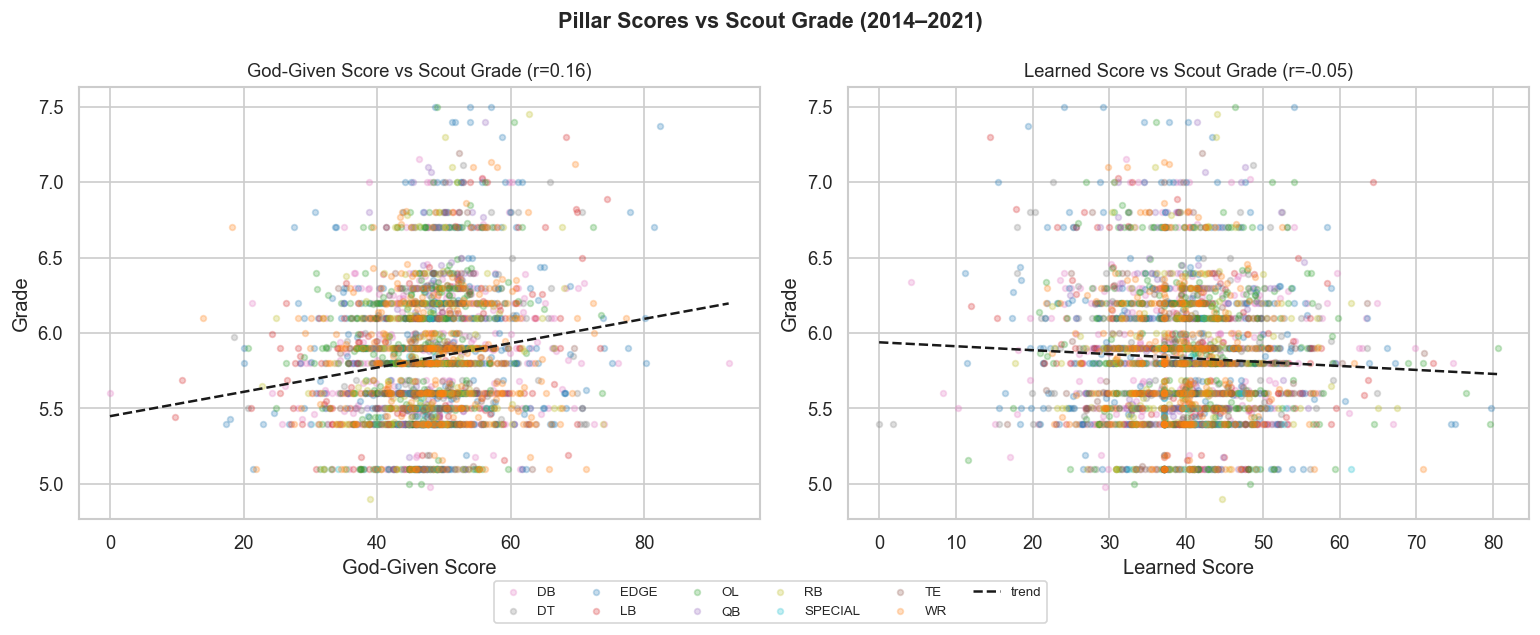

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pos_groups = eda['Pos_Group'].unique()
palette = dict(zip(pos_groups, sns.color_palette('tab10', len(pos_groups))))

for ax, score, label in zip(axes, SCORE_COLS, ['God-Given Score', 'Learned Score']):
    for pg, grp in eda.groupby('Pos_Group'):
        ax.scatter(grp[score], grp['grade'], alpha=0.25, s=12, color=palette[pg], label=pg)
    # overall trend line
    z = np.polyfit(eda[score].dropna(), eda.loc[eda[score].notna(), 'grade'], 1)
    xs = np.linspace(eda[score].min(), eda[score].max(), 100)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1.5, label='trend')
    r = eda[score].corr(eda['grade'])
    ax.set_title(f'{label} vs Scout Grade (r={r:.2f})', fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel('Grade')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Pillar Scores vs Scout Grade (2014–2021)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

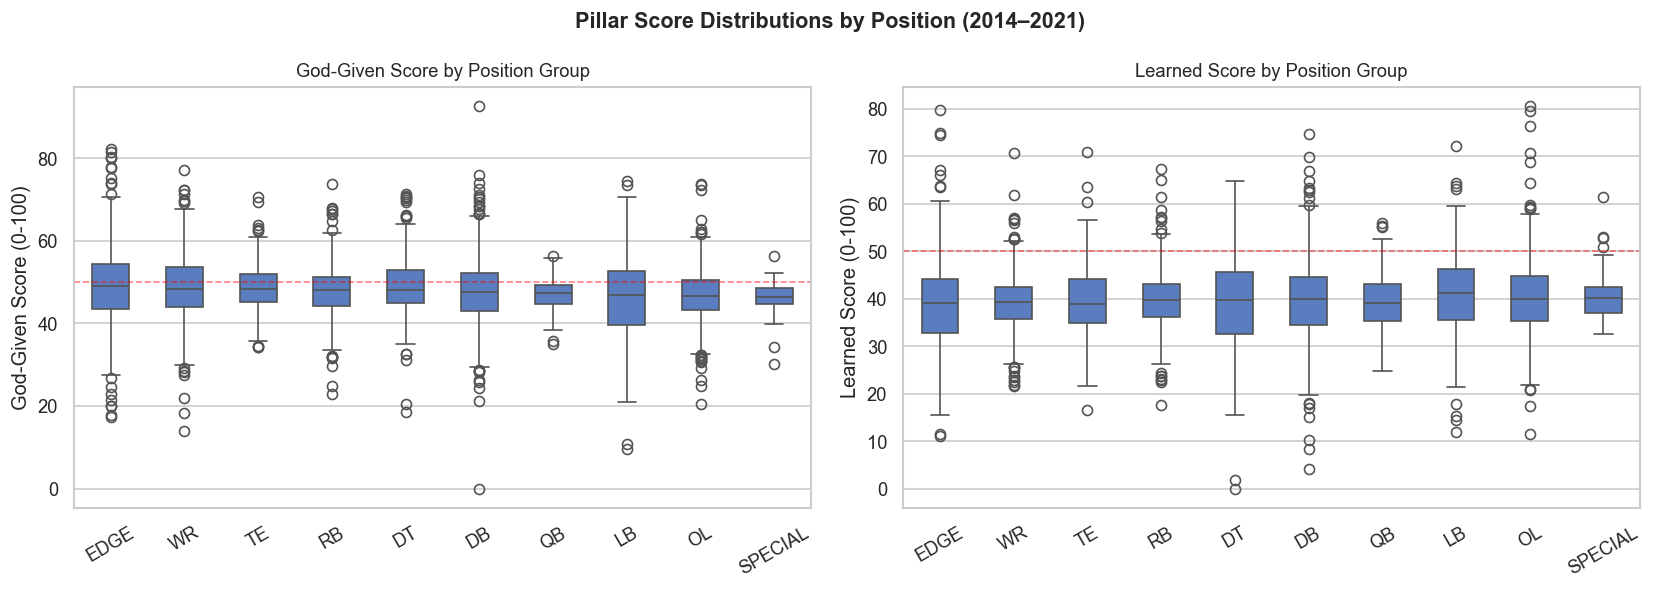

           god_given_med  learned_med  gap (gg-l)
Pos_Group                                        
EDGE                49.0         39.2         9.8
TE                  48.3         38.9         9.4
WR                  48.4         39.3         9.1
DT                  48.2         39.7         8.5
RB                  48.2         39.7         8.5
QB                  47.3         39.2         8.1
DB                  47.5         40.0         7.5
OL                  46.7         40.0         6.7
SPECIAL             46.5         40.2         6.3
LB                  46.8         41.2         5.6


In [6]:
# score distribution by position group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = eda.groupby('Pos_Group')['score_god_given'].median().sort_values(ascending=False).index

for ax, score, label in zip(axes, SCORE_COLS, ['God-Given', 'Learned']):
    sns.boxplot(data=eda, x='Pos_Group', y=score, order=order, ax=ax, width=0.5)
    ax.axhline(50, color='red', lw=1, ls='--', alpha=0.5)
    ax.set_title(f'{label} Score by Position Group', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(f'{label} Score (0-100)')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Pillar Score Distributions by Position (2014–2021)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# median table
med = eda.groupby('Pos_Group')[SCORE_COLS].median().round(1)
med.columns = ['god_given_med', 'learned_med']
med['gap (gg-l)'] = (med['god_given_med'] - med['learned_med']).round(1)
print(med.sort_values('gap (gg-l)', ascending=False).to_string())

---
## 2. Predicting Second Contracts (`made_it_contract`)

Four models compared via 5-fold stratified CV. Primary metric: **PR-AUC** (precision-recall, appropriate for imbalanced outcomes ~31% positive).

| Model | Features |
|---|---|
| Baseline: Grade only | `grade` |
| NLP only | `score_god_given`, `score_learned`, `score_*_pct`, Pos_Group |
| Combined (LR) | grade + NLP + Pos_Group |
| Combined (RF) | grade + NLP + Pos_Group |

In [7]:
# model dataset — drop rows missing grade, outcome, or the two core NLP scores
# NOTE: PCT_COLS (score_*_pct) have 570 NaN — excluded from models to preserve rows
mdf = df.dropna(subset=['grade', 'made_it_contract'] + SCORE_COLS).copy()
mdf['y'] = mdf['made_it_contract'].astype(int)

# one-hot encode Pos_Group
pos_dummies = pd.get_dummies(mdf['Pos_Group'], prefix='pos', drop_first=True)
mdf = pd.concat([mdf, pos_dummies], axis=1)
pos_cols = pos_dummies.columns.tolist()

feat_grade   = ['grade']
feat_nlp     = SCORE_COLS + pos_cols          # PCT_COLS dropped: too many NaN, collinear with SCORE_COLS
feat_combined= ['grade'] + SCORE_COLS + pos_cols

print(f"Model dataset: {mdf.shape[0]:,} rows, {mdf['y'].mean():.1%} positive")
print(f"  (PCT_COLS excluded from models — {df['score_god_given_pct'].isna().sum()} NaN values)")
print(f"Grade features:    {feat_grade}")
print(f"NLP features:      {SCORE_COLS} + {len(pos_cols)} pos dummies")
print(f"Combined features: {['grade'] + SCORE_COLS} + {len(pos_cols)} pos dummies")

Model dataset: 3,244 rows, 31.2% positive
  (PCT_COLS excluded from models — 570 NaN values)
Grade features:    ['grade']
NLP features:      ['score_god_given', 'score_learned'] + 9 pos dummies
Combined features: ['grade', 'score_god_given', 'score_learned'] + 9 pos dummies


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pr_auc_scorer = make_scorer(average_precision_score, needs_proba=True)
roc_scorer    = make_scorer(roc_auc_score, needs_proba=True)

results = {}

def eval_model(name, model, X):
    pr = cross_val_score(model, X, mdf['y'], cv=cv, scoring=pr_auc_scorer)
    roc = cross_val_score(model, X, mdf['y'], cv=cv, scoring=roc_scorer)
    results[name] = {'PR-AUC mean': pr.mean(), 'PR-AUC std': pr.std(),
                     'ROC-AUC mean': roc.mean(), 'ROC-AUC std': roc.std()}
    print(f"  {name:30s}  PR-AUC={pr.mean():.4f} ±{pr.std():.4f}  ROC-AUC={roc.mean():.4f} ±{roc.std():.4f}")

lr = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(C=1.0, max_iter=1000, random_state=42))])
rf = RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=10, random_state=42, n_jobs=-1)

print(f"Baseline (positive rate): {mdf['y'].mean():.4f}\n")
eval_model('Grade only (LR)',          lr, mdf[feat_grade])
eval_model('NLP only (LR)',            lr, mdf[feat_nlp])
eval_model('Grade + NLP (LR)',         lr, mdf[feat_combined])
eval_model('Grade + NLP (RF)',         rf, mdf[feat_combined])

Baseline (positive rate): 0.3120

  Grade only (LR)                 PR-AUC=nan ±nan  ROC-AUC=nan ±nan
  NLP only (LR)                   PR-AUC=nan ±nan  ROC-AUC=nan ±nan
  Grade + NLP (LR)                PR-AUC=nan ±nan  ROC-AUC=nan ±nan
  Grade + NLP (RF)                PR-AUC=nan ±nan  ROC-AUC=nan ±nan


In [10]:
res_df = pd.DataFrame(results).T
res_df['PR-AUC lift vs grade-only'] = res_df['PR-AUC mean'] - results['Grade only (LR)']['PR-AUC mean']
print(res_df[['PR-AUC mean', 'PR-AUC std', 'ROC-AUC mean', 'PR-AUC lift vs grade-only']].round(4).to_string())

                  PR-AUC mean  PR-AUC std  ROC-AUC mean  PR-AUC lift vs grade-only
Grade only (LR)           NaN         NaN           NaN                        NaN
NLP only (LR)             NaN         NaN           NaN                        NaN
Grade + NLP (LR)          NaN         NaN           NaN                        NaN
Grade + NLP (RF)          NaN         NaN           NaN                        NaN


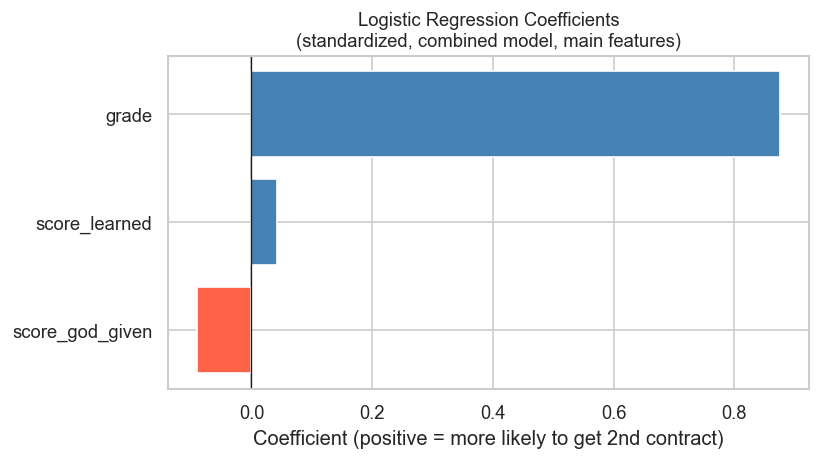

In [11]:
# LR coefficients (combined model) — standardized
scaler = StandardScaler()
X_std = scaler.fit_transform(mdf[feat_combined])
lr_fit = LogisticRegression(C=1.0, max_iter=1000, random_state=42).fit(X_std, mdf['y'])

coef_df = pd.DataFrame({'feature': feat_combined, 'coef': lr_fit.coef_[0]})
coef_df = coef_df[~coef_df['feature'].str.startswith('pos_')]  # hide one-hot noise
coef_df = coef_df.sort_values('coef')

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Logistic Regression Coefficients\n(standardized, combined model, main features)', fontsize=11)
ax.set_xlabel('Coefficient (positive = more likely to get 2nd contract)')
plt.tight_layout()
plt.show()

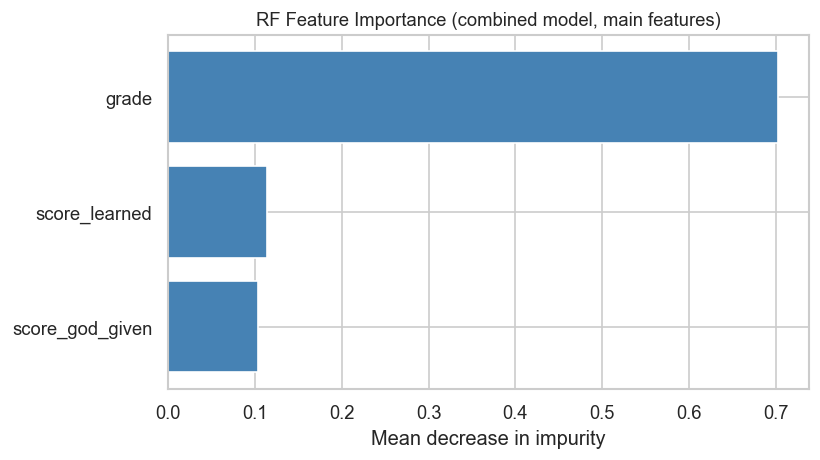

In [12]:
# RF feature importance
rf_fit = RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=10,
                                random_state=42, n_jobs=-1).fit(mdf[feat_combined], mdf['y'])
imp = pd.Series(rf_fit.feature_importances_, index=feat_combined).sort_values(ascending=True)
imp_main = imp[~imp.index.str.startswith('pos_')]  # main features only

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp_main.index, imp_main.values, color='steelblue')
ax.set_title('RF Feature Importance (combined model, main features)', fontsize=11)
ax.set_xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

             n  positive%  PR-AUC (grade)  PR-AUC (combined)  delta
Pos_Group                                                          
DB         610   0.313115             NaN                NaN    NaN
DT         270   0.329630             NaN                NaN    NaN
EDGE       416   0.343750             NaN                NaN    NaN
LB         239   0.343096             NaN                NaN    NaN
OL         549   0.355191             NaN                NaN    NaN
QB         142   0.309859             NaN                NaN    NaN
RB         300   0.256667             NaN                NaN    NaN
TE         179   0.318436             NaN                NaN    NaN
WR         463   0.226782             NaN                NaN    NaN


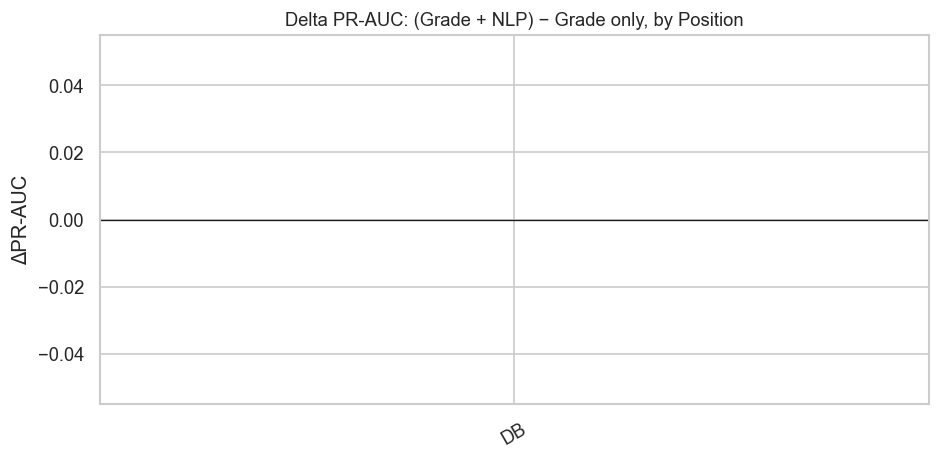

In [13]:
# position-stratified: grade-only LR vs grade+NLP LR, delta PR-AUC
min_pos_n = 100
pos_results = []

for pos, grp in mdf.groupby('Pos_Group'):
    if grp.shape[0] < min_pos_n or grp['y'].sum() < 10:
        continue
    cv_pos = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pr_g  = cross_val_score(lr, grp[feat_grade],    grp['y'], cv=cv_pos, scoring=pr_auc_scorer).mean()
    pr_c  = cross_val_score(lr, grp[feat_combined], grp['y'], cv=cv_pos, scoring=pr_auc_scorer).mean()
    pos_results.append({'Pos_Group': pos, 'n': len(grp), 'positive%': grp['y'].mean(),
                        'PR-AUC (grade)': pr_g, 'PR-AUC (combined)': pr_c,
                        'delta': pr_c - pr_g})

pos_df = pd.DataFrame(pos_results).sort_values('delta', ascending=False)
pos_df[['PR-AUC (grade)', 'PR-AUC (combined)', 'delta']] = pos_df[[
    'PR-AUC (grade)', 'PR-AUC (combined)', 'delta']].round(4)
print(pos_df.set_index('Pos_Group').to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if d >= 0 else 'tomato' for d in pos_df['delta']]
ax.bar(pos_df['Pos_Group'], pos_df['delta'], color=colors)
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Delta PR-AUC: (Grade + NLP) − Grade only, by Position', fontsize=11)
ax.set_ylabel('ΔPR-AUC')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
## 3. Predicting Scout Grade from Pillar Scores

How much of the scout's own grade is explained by the language they wrote?

OLS: `grade ~ score_god_given + score_learned + C(Pos_Group)`

Coefficient direction answers: **does the scout weight god_given traits or learned traits more when assigning a grade?** Players with large positive residuals were graded higher than their language suggests; large negative residuals were graded lower.

In [ ]:
gdf = df.dropna(subset=['grade'] + SCORE_COLS).copy()

formula = 'grade ~ score_god_given + score_learned + C(Pos_Group)'
ols = smf.ols(formula, data=gdf).fit()

print(f"Global OLS: grade ~ score_god_given + score_learned + pos_group")
print(f"  R²      : {ols.rsquared:.4f}")
print(f"  Adj. R² : {ols.rsquared_adj:.4f}")
print(f"  N       : {ols.nobs:.0f}")
print()
# show only the two NLP coefficients cleanly
key_params = ['score_god_given', 'score_learned']
print(ols.summary2().tables[1].loc[key_params, ['Coef.', 'Std.Err.', 't', 'P>|t|']])

In [ ]:
# position-level R² (NLP vs grade)
pos_r2 = []
for pos, grp in gdf.groupby('Pos_Group'):
    if grp.shape[0] < 30:
        continue
    m = smf.ols('grade ~ score_god_given + score_learned', data=grp).fit()
    pos_r2.append({'Pos_Group': pos, 'n': len(grp), 'R²': m.rsquared,
                   'coef_god_given': m.params.get('score_god_given', np.nan),
                   'coef_learned':   m.params.get('score_learned', np.nan)})

pos_r2_df = pd.DataFrame(pos_r2).sort_values('R²', ascending=False)
print(pos_r2_df.set_index('Pos_Group').round(4).to_string())

In [ ]:
gdf['grade_pred'] = ols.fittedvalues
gdf['grade_resid'] = ols.resid    # positive = graded higher than language suggests

# scatter: predicted vs actual, coloured by residual direction
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(gdf['grade_pred'], gdf['grade'], c=gdf['grade_resid'],
                cmap='RdBu_r', alpha=0.4, s=15, vmin=-2, vmax=2)
lims = [gdf['grade_pred'].min()-0.1, gdf['grade_pred'].max()+0.1]
ax.plot(lims, lims, 'k--', lw=1, label='perfect fit')
plt.colorbar(sc, ax=ax, label='Residual (actual − predicted grade)')
ax.set_xlabel('Predicted grade (from NLP scores)')
ax.set_ylabel('Actual scout grade')
ax.set_title('Scout Grade: Actual vs NLP-Predicted', fontsize=11)
plt.tight_layout()
plt.show()

# top positive residuals (over-graded relative to language)
print("=== Top 15: graded HIGHER than language suggests ===")
cols_show = ['player_name', 'Pos_Group', 'grade', 'grade_pred', 'grade_resid',
             'score_god_given', 'score_learned', 'year']
print(gdf.nlargest(15, 'grade_resid')[cols_show].round(2).to_string(index=False))

print()
print("=== Top 15: graded LOWER than language suggests ===")
print(gdf.nsmallest(15, 'grade_resid')[cols_show].round(2).to_string(index=False))

---
## 4. Reach / Steal Analysis — Grade vs Draft Pick

**Approach:** OLS regression residual, not within-cohort ranking.

```
draft_overall ~ grade + C(year) + C(Pos_Group)
reach_score = actual_pick − expected_pick
```

- **`reach_score` < 0** → taken *earlier* than grade implied → **reach** (team paid a premium)
- **`reach_score` > 0** → taken *later* than grade implied → **steal** (team got value)
- Units = **draft picks** (e.g., −45 = taken 45 spots earlier than grade suggested)

Using `draft_overall = (round-1)×32 + pick_in_round` eliminates within-round ties. Year and position confounders absorbed by the OLS model, so residuals are directly comparable across positions and draft classes.

In [ ]:
# drafted players only (all years with grade + draft_overall)
rdf = df.dropna(subset=['grade', 'draft_overall'] + SCORE_COLS).copy()

# OLS: expected draft pick given grade, year, position
# residual = actual_pick - expected_pick
#   negative = reached (taken earlier than grade implied)
#   positive = steal  (taken later than grade implied)
ols_draft = smf.ols('draft_overall ~ grade + C(year) + C(Pos_Group)', data=rdf).fit()

rdf['expected_pick'] = ols_draft.fittedvalues
rdf['reach_score']   = ols_draft.resid      # negative = reach, positive = steal

print(f"Dataset: {rdf.shape[0]:,} drafted players")
print(f"OLS R²: {ols_draft.rsquared:.3f}  (grade + year + position explain this much of draft slot)")
print(f"reach_score range: {rdf['reach_score'].min():.1f} to {rdf['reach_score'].max():.1f} picks")
print(f"  std: {rdf['reach_score'].std():.1f} picks")

In [ ]:
show_cols = ['player_name', 'Pos_Group', 'year', 'grade', 'draft_round', 'draft_overall',
             'expected_pick', 'reach_score', 'score_god_given', 'score_learned']

rdf['gg_premium'] = rdf['score_god_given'] - rdf['score_learned']

print("=== Top 20 REACHES (taken much earlier than grade implied, reach_score most negative) ===")
print(rdf.nsmallest(20, 'reach_score')[show_cols + ['gg_premium']].round(1).to_string(index=False))

print()
print("=== Top 20 STEALS (taken much later than grade implied, reach_score most positive) ===")
print(rdf.nlargest(20, 'reach_score')[show_cols + ['gg_premium']].round(1).to_string(index=False))

In [ ]:
# scatter: reach_score vs god_given premium
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(rdf['gg_premium'], rdf['reach_score'],
                c=rdf['draft_round'], cmap='viridis_r',
                alpha=0.35, s=18)
plt.colorbar(sc, ax=ax, label='Draft Round')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(0, color='k', lw=0.8, ls='--')

# label extreme outliers (beyond 2.5 std)
thresh = rdf['reach_score'].std() * 2.5
outliers = rdf[rdf['reach_score'].abs() > thresh]
for _, row in outliers.iterrows():
    ax.annotate(row['player_name'].split()[-1], (row['gg_premium'], row['reach_score']),
                fontsize=6, alpha=0.7, xytext=(4, 2), textcoords='offset points')

r = rdf['gg_premium'].corr(rdf['reach_score'])
ax.set_title(f'God-Given Premium vs Reach/Steal Score (r={r:.3f})', fontsize=11)
ax.set_xlabel('score_god_given − score_learned  (God-Given Premium)')
ax.set_ylabel('reach_score (picks)\nnegative = reach (taken early), positive = steal (taken late)')
ax.text(0.02, 0.03, 'Reach ↑ (taken earlier than grade implied)',
        transform=ax.transAxes, va='bottom', fontsize=8, color='tomato')
ax.text(0.02, 0.97, 'Steal ↓ (taken later than grade implied)',
        transform=ax.transAxes, va='top', fontsize=8, color='steelblue')
plt.tight_layout()
plt.show()

In [ ]:
# profile reaches vs on-grade vs steals using pick-unit cutoffs
# ±30 picks ≈ roughly 1 round of difference
rdf['type'] = pd.cut(rdf['reach_score'],
                     bins=[-np.inf, -30, 30, np.inf],
                     labels=['Reach (< −30 picks)', 'On-Grade (±30)', 'Steal (> +30 picks)'])

profile = rdf.groupby('type')[SCORE_COLS + ['gg_premium', 'grade']].median().round(1)
profile['n'] = rdf.groupby('type').size()
print("Pillar score profile by reach/steal category (median):")
print(profile.to_string())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
order = ['Reach (< −30 picks)', 'On-Grade (±30)', 'Steal (> +30 picks)']
for ax, col, label in zip(axes,
                           ['score_god_given', 'score_learned', 'gg_premium'],
                           ['God-Given Score', 'Learned Score', 'GG Premium (gg−l)']):
    sns.boxplot(data=rdf.dropna(subset=['type']), x='type', y=col,
                order=order, ax=ax, width=0.5)
    ax.axhline(rdf[col].median(), color='red', lw=1, ls='--', alpha=0.6)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Pillar Score Profile: Reaches vs On-Grade vs Steals', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()